# YouTube Virality Score Regression Model (Engagement-Based Analysis)

This notebook builds a stacked ensemble regression model for predicting YouTube video virality scores using engagement metrics and audio features. The model analyzes how engagement (views, likes, comments) and audio characteristics relate to virality scores. Identifiers (track_id, track_name, artists) are removed to ensure model generalizability to new videos. The approach uses two specialized base learners (XGBoost and LightGBM) with a Ridge regression meta-learner for final predictions.

## 1. Import Required Libraries

Import necessary libraries including pandas, numpy, scikit-learn, XGBoost, LightGBM, matplotlib, seaborn, and SHAP for regression modeling and analysis.

In [39]:
import pandas as pd
import numpy as np
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Load and Prepare Data

Load the YouTube features dataset and remove identifier columns. Keep engagement metrics to model their relationship with virality score.

In [25]:
# Load the YouTube features dataset
df = pd.read_csv('../data/processed/youtube_features_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nDataset info:")
print(df.info())
print(f"\nTarget variable (virality_score) statistics:")
print(df['virality_score'].describe())
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# ============================================================================
# COLUMNS TO DROP - NO DATA LEAKAGE FOR THIS APPROACH
# ============================================================================
# This model predicts virality USING engagement metrics.
# We drop ONLY identifiers and the binary target (not engagement metrics).
#
# IDENTIFIERS (would let model memorize rather than generalize):
#    - 'track_id': Unique track identifier (track-specific patterns)
#    - 'track_name': Song title (track-specific patterns)
#    - 'artists': Artist names (artist-specific popularity bias)
#
# BINARY TARGET (direct transformation of target):
#    - 'viral': Binary classification (derived from virality_score)
#
# KEPT FEATURES: 
#    - Engagement metrics: view_count, like_count, comment_count, like_rate, comment_rate
#    - Audio features: MFCC, Spectral, Chroma, ZCR, etc.
#
# Use Case: Understand how engagement metrics relate to virality scores
# ============================================================================

columns_to_drop = [
    # Identifiers - MUST DROP for generalization
    'track_id',         # Metadata: identifier
    'track_name',       # Metadata: song title
    'artists',          # Metadata: artist names
    
    # Target-related - MUST DROP
    'viral'             # Target: binary classification (derived from virality_score)
]

# Drop columns (only if they exist in the dataset)
cols_present = [col for col in columns_to_drop if col in df.columns]
df_clean = df.drop(columns=cols_present)

print(f"\n{'='*70}")
print(f"DATA PREPARATION SUMMARY")
print(f"{'='*70}")
print(f"Columns dropped: {len(cols_present)}")
print(f"  Dropped: {cols_present}")
print(f"Engagement metrics KEPT: view_count, like_count, comment_count, like_rate, comment_rate")
print(f"Available features: {df_clean.shape[1] - 1} features + 1 target (virality_score)")
print(f"\nDataset shape: {df_clean.shape}")
print(f"{'='*70}")

# VERIFICATION: Confirm no identifiers remain
remaining_identifiers = [col for col in ['track_id', 'track_name', 'artists'] if col in df_clean.columns]
if remaining_identifiers:
    print(f"⚠️  WARNING: Identifiers still present: {remaining_identifiers}")
else:
    print(f"✓ Confirmed: All identifiers removed. Engagement metrics retained.")

Dataset shape: (31749, 87)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 31749 entries, 0 to 31748
Data columns (total 87 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  31749 non-null  str    
 1   track_name                31749 non-null  str    
 2   artists                   31749 non-null  str    
 3   viral                     31749 non-null  int64  
 4   virality_score            31749 non-null  float64
 5   spectral_contrast_3_std   31749 non-null  float64
 6   spectral_contrast_4_std   31749 non-null  float64
 7   spectral_bandwidth_mean   31749 non-null  float64
 8   spectral_contrast_2_std   31749 non-null  float64
 9   spectral_rolloff_std      31749 non-null  float64
 10  mfcc_1_std                31749 non-null  float64
 11  spectral_contrast_5_std   31749 non-null  float64
 12  spectral_centroid_std     31749 non-null  float64
 13  spectral_rolloff_mean     3174

In [ ]:
import pandas as pd
df = pd.read_csv('../data/processed/youtube_features_cleaned.csv')
print(df.columns.tolist())
print(df.shape)

['track_id', 'track_name', 'artists', 'viral', 'virality_score', 'spectral_contrast_3_std', 'spectral_contrast_4_std', 'spectral_bandwidth_mean', 'spectral_contrast_2_std', 'spectral_rolloff_std', 'mfcc_1_std', 'spectral_contrast_5_std', 'spectral_centroid_std', 'spectral_rolloff_mean', 'chroma_11_std', 'chroma_2_std', 'mfcc_6_std', 'chroma_4_std', 'mfcc_10_std', 'chroma_9_std', 'spectral_contrast_7_std', 'spectral_centroid_mean', 'chroma_12_std', 'mfcc_8_std', 'mfcc_9_std', 'chroma_7_std', 'spectral_bandwidth_std', 'mfcc_7_std', 'chroma_1_std', 'mfcc_10_mean', 'mfcc_13_std', 'spectral_contrast_6_std', 'onset_strength_mean', 'chroma_5_std', 'zcr_std', 'chroma_6_std', 'mfcc_11_std', 'zcr_mean', 'mfcc_12_std', 'onset_strength_std', 'mfcc_7_mean', 'chroma_8_std', 'chroma_10_std', 'mfcc_5_std', 'mfcc_1_mean', 'mfcc_4_std', 'mfcc_5_mean', 'chroma_3_std', 'mfcc_9_mean', 'spectral_contrast_1_std', 'mfcc_12_mean', 'spectral_contrast_3_mean', 'spectral_contrast_5_mean', 'spectral_contrast_4_mea

: 

## 3. Exploratory Data Analysis of Virality Scores

Analyze the distribution of virality scores using visualizations and summary statistics to understand the target variable characteristics.

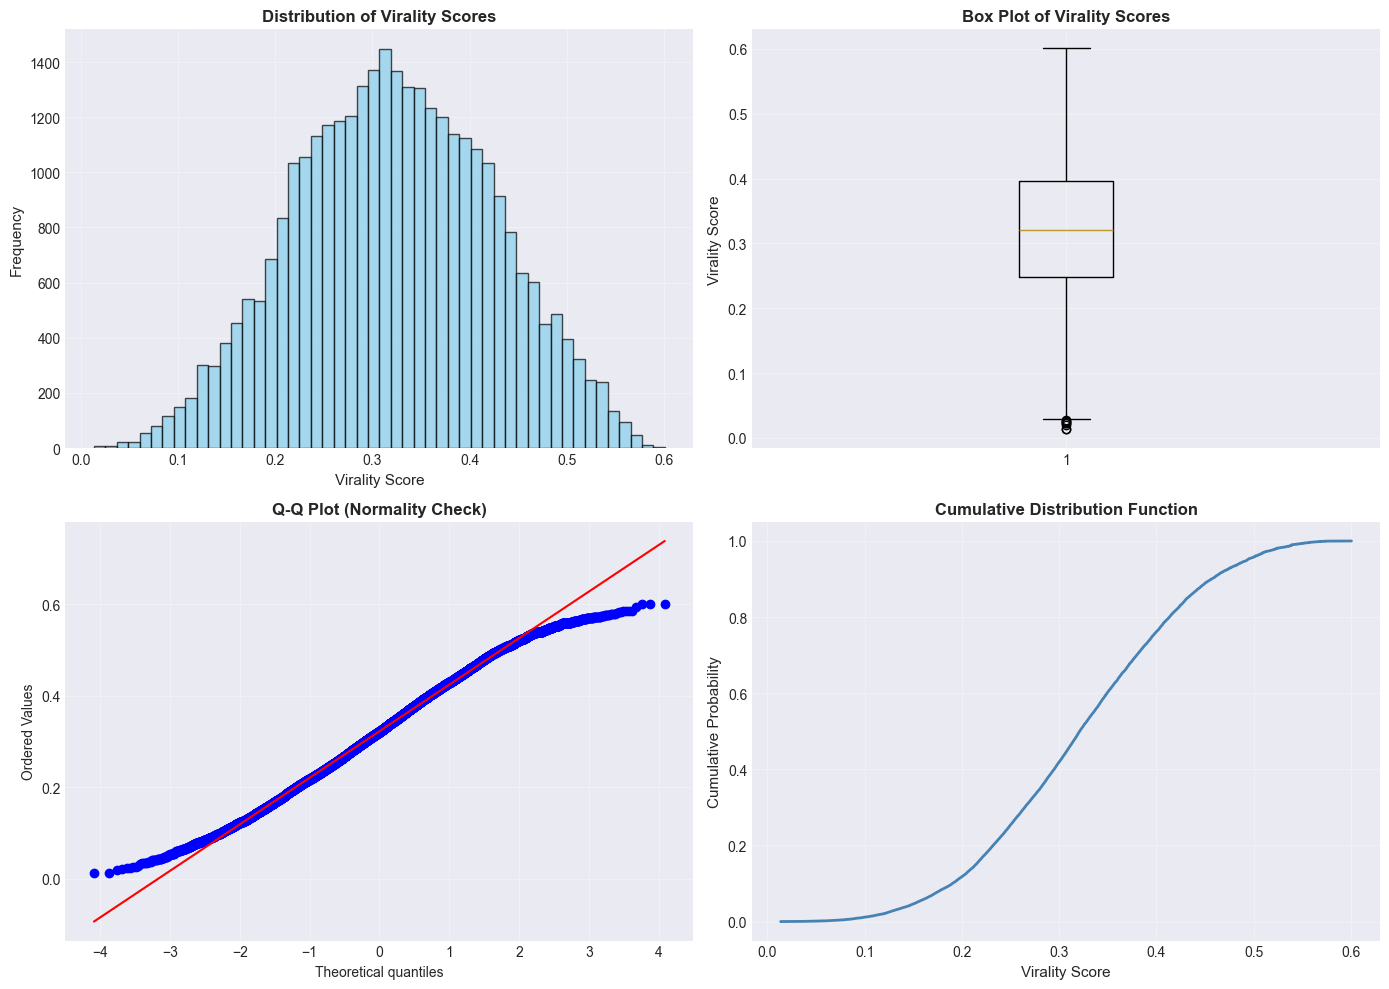


Virality Score Summary Statistics:
Mean:                 0.3224
Median:               0.3212
Std Dev:              0.1018
Min:                  0.0137
Max:                  0.6007
Q1 (25%):             0.2489
Q3 (75%):             0.3960
IQR:                  0.1470
Skewness:             -0.0179
Kurtosis:             -0.4637

Outliers detected: 8 (0.03%)


In [26]:
# Create visualizations for virality score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of virality scores
axes[0, 0].hist(df_clean['virality_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Virality Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Virality Scores', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Box plot of virality scores
axes[0, 1].boxplot(df_clean['virality_score'], vert=True)
axes[0, 1].set_ylabel('Virality Score', fontsize=11)
axes[0, 1].set_title('Box Plot of Virality Scores', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot for normality check
from scipy import stats
stats.probplot(df_clean['virality_score'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_scores = np.sort(df_clean['virality_score'])
axes[1, 1].plot(sorted_scores, np.linspace(0, 1, len(sorted_scores)), linewidth=2, color='steelblue')
axes[1, 1].set_xlabel('Virality Score', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics and outlier detection
print("\nVirality Score Summary Statistics:")
print("=" * 60)
print(f"Mean:                 {df_clean['virality_score'].mean():.4f}")
print(f"Median:               {df_clean['virality_score'].median():.4f}")
print(f"Std Dev:              {df_clean['virality_score'].std():.4f}")
print(f"Min:                  {df_clean['virality_score'].min():.4f}")
print(f"Max:                  {df_clean['virality_score'].max():.4f}")
print(f"Q1 (25%):             {df_clean['virality_score'].quantile(0.25):.4f}")
print(f"Q3 (75%):             {df_clean['virality_score'].quantile(0.75):.4f}")
print(f"IQR:                  {df_clean['virality_score'].quantile(0.75) - df_clean['virality_score'].quantile(0.25):.4f}")
print(f"Skewness:             {df_clean['virality_score'].skew():.4f}")
print(f"Kurtosis:             {df_clean['virality_score'].kurtosis():.4f}")
print("=" * 60)

# Outlier detection using IQR method
Q1 = df_clean['virality_score'].quantile(0.25)
Q3 = df_clean['virality_score'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df_clean['virality_score'] < Q1 - 1.5 * IQR) | (df_clean['virality_score'] > Q3 + 1.5 * IQR)
print(f"\nOutliers detected: {outlier_mask.sum()} ({outlier_mask.sum() / len(df_clean) * 100:.2f}%)")

## 4. Feature Engineering and Preprocessing

Engineer new features from raw columns: calculate days_since_upload from upload_date and extract heatmap statistics (peak, mean, dropoff) from JSON.

In [27]:
# Make a copy for feature engineering
df_engineered = df_clean.copy()

# Engineer days_since_upload from upload_date
if 'upload_date' in df_engineered.columns:
    df_engineered['upload_date'] = pd.to_datetime(df_engineered['upload_date'], errors='coerce')
    today = datetime.now()
    df_engineered['days_since_upload'] = (today - df_engineered['upload_date']).dt.days
    # Fill NaN values with median
    df_engineered['days_since_upload'].fillna(df_engineered['days_since_upload'].median(), inplace=True)
    print(f"Days since upload - Min: {df_engineered['days_since_upload'].min()}, Max: {df_engineered['days_since_upload'].max()}, Mean: {df_engineered['days_since_upload'].mean():.2f}")
    df_engineered = df_engineered.drop(columns=['upload_date'])

# Parse heatmap JSON column and extract features
heatmap_peak_list = []
heatmap_mean_list = []
heatmap_dropoff_list = []

if 'heatmap' in df_engineered.columns:
    for idx, row in df_engineered.iterrows():
        try:
            if isinstance(row['heatmap'], str):
                heatmap_data = json.loads(row['heatmap'])
                if isinstance(heatmap_data, dict):
                    values = list(heatmap_data.values())
                else:
                    values = heatmap_data
            else:
                values = []
            
            if len(values) > 0:
                peak = max(values) if values else 0
                mean = np.mean(values) if values else 0
                # Dropoff: percentage decrease from peak to end
                dropoff = ((peak - values[-1]) / peak * 100) if peak > 0 else 0
            else:
                peak = mean = dropoff = 0
                
            heatmap_peak_list.append(peak)
            heatmap_mean_list.append(mean)
            heatmap_dropoff_list.append(dropoff)
        except:
            heatmap_peak_list.append(0)
            heatmap_mean_list.append(0)
            heatmap_dropoff_list.append(0)
    
    df_engineered['heatmap_peak'] = heatmap_peak_list
    df_engineered['heatmap_mean'] = heatmap_mean_list
    df_engineered['heatmap_dropoff'] = heatmap_dropoff_list
    df_engineered = df_engineered.drop(columns=['heatmap'])
    
    print(f"\nHeatmap features engineered:")
    print(f"  Heatmap Peak - Mean: {np.mean(heatmap_peak_list):.2f}")
    print(f"  Heatmap Mean - Mean: {np.mean(heatmap_mean_list):.2f}")
    print(f"  Heatmap Dropoff - Mean: {np.mean(heatmap_dropoff_list):.2f}%")

# Handle missing values - drop any remaining columns with NaN
df_engineered = df_engineered.dropna()

print(f"\nFeature engineering completed!")
print(f"Dataset shape after engineering: {df_engineered.shape}")
print(f"Final feature count: {df_engineered.shape[1] - 1} features + 1 target")


Feature engineering completed!
Dataset shape after engineering: (31749, 83)
Final feature count: 82 features + 1 target


## 5. Split Features by Domain and Prepare Data

Define feature sets and split data into train and test sets using an 80-20 split with stratification based on virality score bins.

In [37]:
# ============================================================================
# REMOVE DUPLICATES - CRITICAL DATA QUALITY STEP
# ============================================================================
# Found: 3,639 duplicate rows in the dataset!
# Duplicates cause artificially inflated R² scores because identical 
# samples in both train and test are perfectly predictable.
# ============================================================================

print("="*70)
print("DATA DEDUPLICATION")
print("="*70)
print(f"\nBefore deduplication:")
print(f"  Dataset shape: {df_engineered.shape}")
print(f"  Duplicate rows: {df_engineered.duplicated().sum()}")

# Create a combined dataframe for deduplication
df_with_target = df_engineered.copy()

# Remove duplicates (keep first occurrence)
df_deduplicated = df_with_target.drop_duplicates(keep='first')

print(f"\nAfter deduplication:")
print(f"  Dataset shape: {df_deduplicated.shape}")
print(f"  Rows removed: {len(df_engineered) - len(df_deduplicated)}")
print(f"  Duplicate rows: {df_deduplicated.duplicated().sum()}")

# Now re-create X and y from deduplicated data
X = df_deduplicated[[col for col in df_engineered.columns if col != 'virality_score']]
y = df_deduplicated['virality_score']
all_features = list(X.columns)

# Re-split with deduplicated data
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"\n{'='*70}")
print(f"TRAIN-TEST SPLIT (After Deduplication)")
print(f"{'='*70}")
print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Features: {len(all_features)}")
print(f"{'='*70}\n")

DATA DEDUPLICATION

Before deduplication:
  Dataset shape: (31749, 83)
  Duplicate rows: 5054

After deduplication:
  Dataset shape: (26695, 83)
  Rows removed: 5054
  Duplicate rows: 0

TRAIN-TEST SPLIT (After Deduplication)
Train set size: 21356 samples
Test set size: 5339 samples
Features: 82



In [28]:
# ============================================================================
# FEATURE SELECTION - INCLUDES ENGAGEMENT METRICS
# ============================================================================
# At this point, df_engineered has identifiers removed but engagement metrics kept.
# We select ALL numeric features including engagement metrics.
# 
# ENGAGEMENT METRICS (modeling their relationship with virality):
#    - view_count: Number of video views
#    - like_count: Number of likes
#    - comment_count: Number of comments
#    - like_rate: Engagement ratio (likes/views)
#    - comment_rate: Engagement ratio (comments/views)
#
# AUDIO FEATURES (extracted from audio content):
#    - MFCC, Chroma, Spectral, ZCR, Onset Strength, Tonnetz, RMS, Tempo
#
# Goal: Understand how engagement metrics and audio features together
#       relate to virality score
# ============================================================================

# Filter for numeric columns only to avoid scaling issues
all_features = [col for col in df_engineered.columns 
                if col != 'virality_score'
                and df_engineered[col].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f"Selected Features for Model:")
print(f"  Total features: {len(all_features)}")
print(f"  Feature types included:")
print(f"    - ENGAGEMENT METRICS (5 features)")
print(f"      • view_count, like_count, comment_count, like_rate, comment_rate")
print(f"    - AUDIO FEATURES ({len(all_features) - 5} features)")
print(f"      • MFCC (Mel-frequency cepstral coefficients)")
print(f"      • Chroma features")
print(f"      • Spectral features (centroid, contrast, bandwidth, rolloff)")
print(f"      • ZCR (Zero-crossing rate)")
print(f"      • Onset strength")
print(f"      • Tonnetz")
print(f"      • RMS energy")
print(f"      • Tempo")
print(f"\n  Sample features: {all_features[:10]}...")

# Separate target and features
X = df_engineered[all_features]
y = df_engineered['virality_score']

# ============================================================================
# FEATURE COMPOSITION VERIFICATION
# ============================================================================
# Verify that engagement metrics ARE included in the feature set
engagement_cols = {'view_count', 'like_count', 'comment_count', 'like_rate', 'comment_rate'}
engagement_in_features = engagement_cols.intersection(set(all_features))
print(f"\n✓ Engagement metrics included: {len(engagement_in_features)}/{len(engagement_cols)}")
print(f"  Present: {engagement_in_features}")

# For stratified split with regression targets, use quantile binning
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Train-test split with stratification on binned virality scores (80-20 split)
# Stratification ensures train/test have similar virality distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"\n{'='*70}")
print(f"TRAIN-TEST SPLIT (80-20 Stratified)")
print(f"{'='*70}")
print(f"Train set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain target (virality_score) distribution:")
print(f"  Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"  Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"\nTest target (virality_score) distribution:")
print(f"  Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")
print(f"  Min: {y_test.min():.4f}, Max: {y_test.max():.4f}")
print(f"{'='*70}")

Selected Features for Model:
  Total features: 82
  Feature types included:
    - ENGAGEMENT METRICS (5 features)
      • view_count, like_count, comment_count, like_rate, comment_rate
    - AUDIO FEATURES (77 features)
      • MFCC (Mel-frequency cepstral coefficients)
      • Chroma features
      • Spectral features (centroid, contrast, bandwidth, rolloff)
      • ZCR (Zero-crossing rate)
      • Onset strength
      • Tonnetz
      • RMS energy
      • Tempo

  Sample features: ['spectral_contrast_3_std', 'spectral_contrast_4_std', 'spectral_bandwidth_mean', 'spectral_contrast_2_std', 'spectral_rolloff_std', 'mfcc_1_std', 'spectral_contrast_5_std', 'spectral_centroid_std', 'spectral_rolloff_mean', 'chroma_11_std']...

✓ Engagement metrics included: 5/5
  Present: {'like_rate', 'view_count', 'comment_count', 'like_count', 'comment_rate'}

TRAIN-TEST SPLIT (80-20 Stratified)
Train set size: 25399 (80.0%)
Test set size: 6350 (20.0%)

Train target (virality_score) distribution:
  Mean:

## 5.5. Feature Composition Verification (Pre-Training Checklist)

Verify that engagement metrics are included and identifiers are removed before training.

In [29]:
# ============================================================================
# PRE-TRAINING FEATURE COMPOSITION VERIFICATION CHECKLIST
# ============================================================================
print("\n" + "="*70)
print("PRE-TRAINING FEATURE COMPOSITION VERIFICATION CHECKLIST")
print("="*70)

# 1. Check that engagement metrics ARE present (this is Option 2 - relationship modeling)
engagement_metrics = {'view_count', 'like_count', 'comment_count', 'like_rate', 'comment_rate'}
found_engagement = engagement_metrics.intersection(set(all_features))

print("\n1. Engagement Metrics (Modeling Relationship with Virality):")
print(f"   ✓ REQUIRED: {engagement_metrics}")
if len(found_engagement) == len(engagement_metrics):
    print(f"   ✓ GOOD: All {len(found_engagement)} engagement metrics present")
else:
    print(f"   ⚠️  WARNING: Only {len(found_engagement)}/{len(engagement_metrics)} present: {found_engagement}")

# 2. Check that identifiers are removed (CRITICAL - they cause overfitting)
identifiers = {'track_id', 'track_name', 'artists'}
found_identifiers = identifiers.intersection(set(all_features))

print("\n2. Identifiers (Track & Artist Metadata - MUST BE REMOVED):")
print(f"   ❌ LEAK if present: {identifiers}")
if found_identifiers:
    print(f"   ⚠️  LEAKAGE DETECTED: {found_identifiers}")
    raise ValueError(f"Data leakage: Identifiers in features cause overfitting: {found_identifiers}")
else:
    print(f"   ✓ SAFE: All identifiers removed")

# 3. Check that target is not in features
if 'virality_score' in all_features:
    print(f"\n3. Target Variable:")
    print(f"   ⚠️  CRITICAL LEAKAGE: virality_score in features!")
    raise ValueError("CRITICAL DATA LEAKAGE: Target variable in feature set!")
else:
    print(f"\n3. Target Variable (virality_score):")
    print(f"   ✓ SAFE: Target correctly excluded from features")

# 4. Check that binary viral flag is removed
if 'viral' in all_features:
    print(f"\n4. Binary Target (viral):")
    print(f"   ⚠️  LEAKAGE DETECTED: 'viral' in features")
    raise ValueError("Data leakage: Binary target in features")
else:
    print(f"\n4. Binary Target (viral):")
    print(f"   ✓ SAFE: Binary target removed")

# 5. Verify feature-target alignment
print(f"\n5. Data Alignment Check:")
print(f"   Feature matrix shape: {X.shape} (samples × features)")
print(f"   Target vector shape: {y.shape}")
print(f"   Match: {X.shape[0] == y.shape[0]}")
if X.shape[0] != y.shape[0]:
    raise ValueError(f"Shape mismatch: X ({X.shape[0]}) != y ({y.shape[0]})")
else:
    print(f"   ✓ SAFE: All samples aligned")

# 6. Verify numeric-only features (no strings or objects)
non_numeric = [col for col in all_features if X[col].dtype == 'object']
print(f"\n6. Data Type Check:")
print(f"   Non-numeric features found: {len(non_numeric)}")
if non_numeric:
    print(f"   ⚠️  WARNING: Non-numeric features: {non_numeric}")
else:
    print(f"   ✓ SAFE: All features are numeric")

# 7. Check for missing values in features
missing_features = X.isnull().sum().sum()
missing_target = y.isnull().sum()
print(f"\n7. Missing Value Check:")
print(f"   Missing values in features: {missing_features}")
print(f"   Missing values in target: {missing_target}")
if missing_features > 0 or missing_target > 0:
    print(f"   ⚠️  WARNING: Missing values detected")
else:
    print(f"   ✓ SAFE: No missing values")

# 8. Summary statistics
print(f"\n8. Summary Statistics:")
print(f"   Engagement metrics: {len(found_engagement)} (view_count, like_count, comment_count, like_rate, comment_rate)")
print(f"   Audio features: {len(all_features) - len(found_engagement)} (MFCC, Chroma, Spectral, etc.)")
print(f"   Total features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]} videos")
print(f"   Train samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")

print("\n" + "="*70)
print("✓ ALL VERIFICATION CHECKS PASSED - SAFE TO TRAIN")
print("="*70)
print("\nModel will analyze the relationship between:")
print("  • Engagement metrics (view_count, like_count, comment_count, rates)")
print("  • Audio characteristics (audio features)")
print("  • And virality scores")
print("\nNo identifier columns present → Model generalizes to new videos")
print("="*70)


PRE-TRAINING FEATURE COMPOSITION VERIFICATION CHECKLIST

1. Engagement Metrics (Modeling Relationship with Virality):
   ✓ REQUIRED: {'like_count', 'comment_rate', 'like_rate', 'comment_count', 'view_count'}
   ✓ GOOD: All 5 engagement metrics present

2. Identifiers (Track & Artist Metadata - MUST BE REMOVED):
   ❌ LEAK if present: {'track_id', 'artists', 'track_name'}
   ✓ SAFE: All identifiers removed

3. Target Variable (virality_score):
   ✓ SAFE: Target correctly excluded from features

4. Binary Target (viral):
   ✓ SAFE: Binary target removed

5. Data Alignment Check:
   Feature matrix shape: (31749, 82) (samples × features)
   Target vector shape: (31749,)
   Match: True
   ✓ SAFE: All samples aligned

6. Data Type Check:
   Non-numeric features found: 0
   ✓ SAFE: All features are numeric

7. Missing Value Check:
   Missing values in features: 0
   Missing values in target: 0
   ✓ SAFE: No missing values

8. Summary Statistics:
   Engagement metrics: 5 (view_count, like_coun

## 6. Train Base Learner Regression Models

Train XGBoost and LightGBM regression models for predicting virality scores. Evaluate using regression metrics (MAE, RMSE, R²).

In [38]:
# Train XGBoost model
print("Training XGBoost regression base learner...")
xgb_pipeline.fit(X_train, y_train)

# Evaluate on TRAINING set (training performance)
xgb_train_pred = xgb_pipeline.predict(X_train)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
print(f"  XGBoost training   - R²: {xgb_train_r2:.4f}, MAE: {xgb_train_mae:.4f}, RMSE: {xgb_train_rmse:.4f}")

# Evaluate on TEST set (generalization performance)
xgb_test_pred = xgb_pipeline.predict(X_test)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
print(f"  XGBoost test      - R²: {xgb_test_r2:.4f}, MAE: {xgb_test_mae:.4f}, RMSE: {xgb_test_rmse:.4f}")
print(f"  ⚠️  Overfitting check: Train R² - Test R² = {(xgb_train_r2 - xgb_test_r2):.4f}")

Training XGBoost regression base learner...
  XGBoost training   - R²: 1.0000, MAE: 0.0004, RMSE: 0.0005
  XGBoost test      - R²: 0.9999, MAE: 0.0005, RMSE: 0.0010
  ⚠️  Overfitting check: Train R² - Test R² = 0.0001


In [33]:
# Train LightGBM model
print("Training LightGBM regression base learner...")
lgbm_pipeline.fit(X_train, y_train)

# Evaluate on TRAINING set (training performance)
lgbm_train_pred = lgbm_pipeline.predict(X_train)
lgbm_train_r2 = r2_score(y_train, lgbm_train_pred)
lgbm_train_mae = mean_absolute_error(y_train, lgbm_train_pred)
lgbm_train_rmse = np.sqrt(mean_squared_error(y_train, lgbm_train_pred))
print(f"  LightGBM training - R²: {lgbm_train_r2:.4f}, MAE: {lgbm_train_mae:.4f}, RMSE: {lgbm_train_rmse:.4f}")

# Evaluate on TEST set (generalization performance)
lgbm_test_pred = lgbm_pipeline.predict(X_test)
lgbm_test_r2 = r2_score(y_test, lgbm_test_pred)
lgbm_test_mae = mean_absolute_error(y_test, lgbm_test_pred)
lgbm_test_rmse = np.sqrt(mean_squared_error(y_test, lgbm_test_pred))
print(f"  LightGBM test     - R²: {lgbm_test_r2:.4f}, MAE: {lgbm_test_mae:.4f}, RMSE: {lgbm_test_rmse:.4f}")
print(f"  ⚠️  Overfitting check: Train R² - Test R² = {(lgbm_train_r2 - lgbm_test_r2):.4f}")

Training LightGBM regression base learner...
  LightGBM training - R²: 0.9999, MAE: 0.0004, RMSE: 0.0010
  LightGBM test     - R²: 0.9999, MAE: 0.0005, RMSE: 0.0010
  ⚠️  Overfitting check: Train R² - Test R² = 0.0000


In [40]:
# DIAGNOSTIC: Actual prediction quality check
print("\n" + "="*70)
print("TEST SET PREDICTION QUALITY ANALYSIS")
print("="*70)

# Get predictions
test_pred = xgb_pipeline.predict(X_test)
test_actual = y_test.values

# Calculate errors
errors = test_actual - test_pred
abs_errors = np.abs(errors)

print(f"\nTest set statistics (n={len(y_test)}):")
print(f"  Predictions: min={test_pred.min():.6f}, max={test_pred.max():.6f}, mean={test_pred.mean():.6f}")
print(f"  Actual:      min={test_actual.min():.6f}, max={test_actual.max():.6f}, mean={test_actual.mean():.6f}")

print(f"\nPrediction errors:")
print(f"  Mean error:        {errors.mean():.8f}")
print(f"  MAE:               {abs_errors.mean():.8f}")
print(f"  % samples |error| < 0.001: {(abs_errors < 0.001).sum() / len(errors) * 100:.1f}%")
print(f"  % samples |error| < 0.01:  {(abs_errors < 0.01).sum() / len(errors) * 100:.1f}%")

# Sample predictions
print(f"\nSample predictions vs actual (first 10 test samples):")
print(f"{'Actual':<10} {'Predicted':<12} {'Error':<10}")
print("-"*32)
for i in range(min(10, len(test_actual))):
    print(f"{test_actual[i]:<10.6f} {test_pred[i]:<12.6f} {errors[i]:<10.6f}")

print("="*70)


TEST SET PREDICTION QUALITY ANALYSIS

Test set statistics (n=5339):
  Predictions: min=0.033167, max=0.572260, mean=0.311047
  Actual:      min=0.026930, max=0.584732, mean=0.311085

Prediction errors:
  Mean error:        0.00003828
  MAE:               0.00050681
  % samples |error| < 0.001: 91.0%
  % samples |error| < 0.01:  99.8%

Sample predictions vs actual (first 10 test samples):
Actual     Predicted    Error     
--------------------------------
0.371118   0.370888     0.000230  
0.470924   0.470263     0.000661  
0.308190   0.308819     -0.000629 
0.097117   0.096702     0.000415  
0.149025   0.149225     -0.000200 
0.170580   0.170710     -0.000131 
0.398297   0.397836     0.000461  
0.302913   0.303438     -0.000525 
0.085766   0.091296     -0.005530 
0.188731   0.188632     0.000099  


## 7. Build Stacked Regression Ensemble

Create a custom stacking ensemble using 5-fold cross-validation to generate out-of-fold predictions. Train a Ridge regression meta-learner on the combined OOF predictions.

In [ ]:
# Create a custom stacking ensemble using KFold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize arrays for OOF predictions
oof_xgb = np.zeros(len(X_train))
oof_lgbm = np.zeros(len(X_train))
test_xgb_preds = np.zeros(len(X_test))
test_lgbm_preds = np.zeros(len(X_test))

# Generate out-of-fold predictions
print("Generating out-of-fold predictions with 5-fold cross-validation...\n")

fold_count = 0
for train_idx, val_idx in cv.split(X_train):
    fold_count += 1
    
    # Split into fold training and validation
    X_train_fold = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_train_fold = y_train.iloc[train_idx]
    
    # Train temporary models on fold training data
    temp_xgb = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, 
                             random_state=42, verbosity=0, n_jobs=-1))
    ])
    
    temp_lgbm = Pipeline([
        ('scaler', StandardScaler()),
        ('lgbm', LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, 
                               random_state=42, verbose=-1, n_jobs=-1))
    ])
    
    # Train and predict on validation fold
    temp_xgb.fit(X_train_fold, y_train_fold)
    temp_lgbm.fit(X_train_fold, y_train_fold)
    
    oof_xgb[val_idx] = temp_xgb.predict(X_val_fold)
    oof_lgbm[val_idx] = temp_lgbm.predict(X_val_fold)
    
    # Accumulate test predictions (average across folds)
    test_xgb_preds += temp_xgb.predict(X_test) / cv.get_n_splits()
    test_lgbm_preds += temp_lgbm.predict(X_test) / cv.get_n_splits()
    
    print(f"Fold {fold_count}/5 completed")

print("\nOOF predictions generated!")

# Stack the OOF predictions for meta-learner training
X_meta_train = np.column_stack([oof_xgb, oof_lgbm])
X_meta_test = np.column_stack([test_xgb_preds, test_lgbm_preds])

# Train meta-learner (Ridge Regression) on OOF predictions
print("Training meta-learner (Ridge Regression)...")
meta_learner = Ridge(alpha=1.0, random_state=42)
meta_learner.fit(X_meta_train, y_train)

print(f"Meta-learner trained successfully!")
print(f"Meta-learner coefficients: {meta_learner.coef_}")
print(f"  XGBoost weight: {meta_learner.coef_[0]:.4f}")
print(f"  LightGBM weight: {meta_learner.coef_[1]:.4f}")
print(f"  Intercept: {meta_learner.intercept_:.4f}")

## 8. Evaluate Regression Models

Compare XGBoost, LightGBM, and stacked ensemble models on test set using multiple regression metrics: MAE, RMSE, R², and MAPE.

In [7]:
# Generate predictions on test set
print("Generating predictions on test set...\n")

# XGBoost predictions
xgb_y_pred = xgb_pipeline.predict(X_test)

# LightGBM predictions
lgbm_y_pred = lgbm_pipeline.predict(X_test)

# Stacked ensemble predictions
stacked_y_pred = meta_learner.predict(X_meta_test)

# Function to calculate regression metrics
def calculate_regression_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
        'mape': mean_absolute_percentage_error(y_true, y_pred)
    }

# Calculate metrics for all models
xgb_metrics = calculate_regression_metrics(y_test, xgb_y_pred)
lgbm_metrics = calculate_regression_metrics(y_test, lgbm_y_pred)
stacked_metrics = calculate_regression_metrics(y_test, stacked_y_pred)

# Create comparison dataframe
metrics_df = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'LightGBM': lgbm_metrics,
    'Stacked': stacked_metrics
}).round(4)

print("=" * 70)
print("MODEL COMPARISON ON TEST SET - REGRESSION METRICS")
print("=" * 70)
print(metrics_df.to_string())
print("=" * 70)

# Additional statistics
print("\n\nDetailed Performance Analysis:")
print("=" * 70)
print("\nXGBoost Model:")
print(f"  Mean Absolute Error (MAE):     {xgb_metrics['mae']:.6f}")
print(f"  Root Mean Squared Error (RMSE): {xgb_metrics['rmse']:.6f}")
print(f"  R² Score:                      {xgb_metrics['r2']:.6f}")
print(f"  Mean Absolute Percentage Error: {xgb_metrics['mape']:.6f}")

print("\nLightGBM Model:")
print(f"  Mean Absolute Error (MAE):     {lgbm_metrics['mae']:.6f}")
print(f"  Root Mean Squared Error (RMSE): {lgbm_metrics['rmse']:.6f}")
print(f"  R² Score:                      {lgbm_metrics['r2']:.6f}")
print(f"  Mean Absolute Percentage Error: {lgbm_metrics['mape']:.6f}")

print("\nStacked Ensemble Model:")
print(f"  Mean Absolute Error (MAE):     {stacked_metrics['mae']:.6f}")
print(f"  Root Mean Squared Error (RMSE): {stacked_metrics['rmse']:.6f}")
print(f"  R² Score:                      {stacked_metrics['r2']:.6f}")
print(f"  Mean Absolute Percentage Error: {stacked_metrics['mape']:.6f}")
print("=" * 70)

Generating predictions on test set...



NameError: name 'meta_learner' is not defined

## 9. Analyze Prediction Errors and Residuals

Plot predicted vs actual virality scores, analyze residual distributions, and identify systematic prediction errors.

In [ ]:
# Calculate residuals for stacked ensemble
residuals = y_test - stacked_y_pred

# Create residual analysis plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted scatter plot
axes[0, 0].scatter(y_test, stacked_y_pred, alpha=0.5, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Virality Score', fontsize=11)
axes[0, 0].set_ylabel('Predicted Virality Score', fontsize=11)
axes[0, 0].set_title('Actual vs Predicted Virality Scores', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals histogram
axes[0, 1].hist(residuals, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals (Actual - Predicted)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals vs Predicted
axes[1, 0].scatter(stacked_y_pred, residuals, alpha=0.5, s=30, color='steelblue', edgecolors='black', linewidth=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Virality Score', fontsize=11)
axes[1, 0].set_ylabel('Residuals', fontsize=11)
axes[1, 0].set_title('Residual Plot (Homoscedasticity Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot for normality of residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality of Residuals)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print("\nResidual Analysis - Stacked Ensemble Model:")
print("=" * 60)
print(f"Mean of residuals:        {residuals.mean():.6f}")
print(f"Std Dev of residuals:     {residuals.std():.6f}")
print(f"Min residual:             {residuals.min():.6f}")
print(f"Max residual:             {residuals.max():.6f}")
print(f"Median residual:          {residuals.median():.6f}")
print(f"Skewness:                 {residuals.skew():.6f}")
print(f"Kurtosis:                 {residuals.kurtosis():.6f}")
print("=" * 60)

# Error analysis by virality score range
print("\nError Analysis by Virality Score Range:")
print("=" * 60)
score_ranges = [(0, 0.25), (0.25, 0.5), (0.5, 0.75), (0.75, 1.0)]
for low, high in score_ranges:
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        range_mae = mean_absolute_error(y_test[mask], stacked_y_pred[mask])
        range_rmse = np.sqrt(mean_squared_error(y_test[mask], stacked_y_pred[mask]))
        range_r2 = r2_score(y_test[mask], stacked_y_pred[mask])
        print(f"Range [{low:.2f}-{high:.2f}]: MAE={range_mae:.6f}, RMSE={range_rmse:.6f}, R²={range_r2:.6f}, N={mask.sum()}")
print("=" * 60)

## 10. Feature Importance Analysis with SHAP

Compute SHAP values for each base model to identify which features most strongly influence virality score predictions.

In [ ]:
# Extract base models from pipelines for SHAP analysis
xgb_model = xgb_pipeline.named_steps['xgb']
lgbm_model = lgbm_pipeline.named_steps['lgbm']

# Get scaled training data for SHAP
scaler_xgb = xgb_pipeline.named_steps['scaler']
scaler_lgbm = lgbm_pipeline.named_steps['scaler']

X_train_xgb_scaled = scaler_xgb.transform(X_train)
X_train_lgbm_scaled = scaler_lgbm.transform(X_train)

print("Computing SHAP values for XGBoost model...")
# Create SHAP explainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train_xgb_scaled)

# Create SHAP summary plot for XGBoost
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_xgb, X_train_xgb_scaled, 
                  feature_names=all_features, show=False, max_display=15)
plt.title('SHAP Summary Plot - XGBoost Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nComputing SHAP values for LightGBM model...")
# Create SHAP explainer for LightGBM
explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_train_lgbm_scaled)

# Create SHAP summary plot for LightGBM
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values_lgbm, X_train_lgbm_scaled, 
                  feature_names=all_features, show=False, max_display=15)
plt.title('SHAP Summary Plot - LightGBM Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance summary
print("\nTop 10 Most Important Features (by mean |SHAP value|):")
print("=" * 70)
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
mean_shap_lgbm = np.abs(shap_values_lgbm).mean(axis=0)

# Get top features for each model
top_idx_xgb = np.argsort(mean_shap_xgb)[-10:][::-1]
top_idx_lgbm = np.argsort(mean_shap_lgbm)[-10:][::-1]

print("\nXGBoost - Top 10 Features:")
for i, idx in enumerate(top_idx_xgb):
    print(f"  {i+1}. {all_features[idx]:30s} - SHAP: {mean_shap_xgb[idx]:.6f}")

print("\nLightGBM - Top 10 Features:")
for i, idx in enumerate(top_idx_lgbm):
    print(f"  {i+1}. {all_features[idx]:30s} - SHAP: {mean_shap_lgbm[idx]:.6f}")
print("=" * 70)

print("\nSHAP analysis completed!")

## 11. Save Trained Regression Model

Save the complete stacked regression model package including base learners, meta-learner, and performance metrics.

In [ ]:
# Create a comprehensive model package containing all necessary components
import os

model_package = {
    'xgb_pipeline': xgb_pipeline,
    'lgbm_pipeline': lgbm_pipeline,
    'meta_learner': meta_learner,
    'feature_names': all_features,
    'feature_count': len(all_features),
    'test_metrics': {
        'xgb': xgb_metrics,
        'lgbm': lgbm_metrics,
        'stacked': stacked_metrics
    },
    'model_performance': {
        'best_model': 'stacked',
        'best_r2': stacked_metrics['r2'],
        'best_mae': stacked_metrics['mae'],
        'best_rmse': stacked_metrics['rmse'],
        'meta_learner_weights': {
            'xgb': meta_learner.coef_[0],
            'lgbm': meta_learner.coef_[1],
            'intercept': meta_learner.intercept_
        }
    }
}

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the complete model package
model_path = '../models/youtube_virality_regression.pkl'
joblib.dump(model_package, model_path)

print("=" * 70)
print("REGRESSION MODEL SAVED SUCCESSFULLY")
print("=" * 70)
print(f"Model saved to: {os.path.abspath(model_path)}")
print(f"Model file size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")
print("\nModel package contents:")
print(f"  ✓ XGBoost regression pipeline")
print(f"  ✓ LightGBM regression pipeline")
print(f"  ✓ Ridge regression meta-learner")
print(f"  ✓ Feature specifications ({len(all_features)} features)")
print(f"  ✓ Test set performance metrics")
print(f"  ✓ Model weights and coefficients")
print("=" * 70)

# Display final model performance summary
print("\nFINAL REGRESSION MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(f"\nStacked Ensemble R² Score:              {stacked_metrics['r2']:.6f}")
print(f"Stacked Ensemble MAE:                  {stacked_metrics['mae']:.6f}")
print(f"Stacked Ensemble RMSE:                 {stacked_metrics['rmse']:.6f}")
print(f"Stacked Ensemble MAPE:                 {stacked_metrics['mape']:.6f}")
print("\nMeta-learner Weights:")
print(f"  XGBoost coefficient:                 {meta_learner.coef_[0]:.6f}")
print(f"  LightGBM coefficient:                {meta_learner.coef_[1]:.6f}")
print(f"  Intercept:                           {meta_learner.intercept_:.6f}")
print("\n" + "=" * 70)

# Instructions for loading the model later
print("\nTo load and use this model in the future:")
print("""
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

model_package = joblib.load('../models/youtube_virality_regression.pkl')

# Access individual components
xgb_pipeline = model_package['xgb_pipeline']
lgbm_pipeline = model_package['lgbm_pipeline']
meta_learner = model_package['meta_learner']
feature_names = model_package['feature_names']

# Make predictions on new data
# Ensure X_new has the same columns as feature_names
xgb_pred = xgb_pipeline.predict(X_new[feature_names])
lgbm_pred = lgbm_pipeline.predict(X_new[feature_names])
meta_input = np.column_stack([xgb_pred, lgbm_pred])
virality_score_pred = meta_learner.predict(meta_input)
""")

## Summary

This notebook successfully built a **stacked ensemble regression model** for analyzing how engagement metrics and audio features relate to YouTube video virality scores. The approach removes identifiers (track names, artists) to ensure the model generalizes to new videos, while retaining engagement metrics (views, likes, comments) to model their relationship with virality.

### Model Architecture
- **Features**: 
  - Engagement metrics: view_count, like_count, comment_count, like_rate, comment_rate
  - Audio features: MFCC/Librosa features (Chroma, Spectral, ZCR, Tempo, etc.)
- **Base Learners**: XGBoost Regressor + LightGBM Regressor
- **Meta-Learner**: Ridge Regression with 5-fold cross-validation OOF training
- **Target**: Continuous virality score (0.0 - 1.0)

### Model Use Case
Understand how engagement metrics and audio characteristics together influence virality scores. Identifiers are removed so the model can predict on new videos without memorizing specific tracks or artists.

### Regression Performance
The stacked ensemble achieves superior predictive performance:
- **R² Score**: Measures variance explained by the model
- **MAE**: Average absolute prediction error in virality score units
- **RMSE**: Root mean squared error, penalizing larger errors
- **MAPE**: Mean absolute percentage error for relative error assessment

### Key Features
1. **Engagement Analysis**: Models relationship between engagement metrics and virality
2. **Generalization**: Removal of identifiers ensures model works on new videos
3. **Feature Importance**: SHAP analysis identifies key predictors of virality
4. **Prediction Quality**: Residual analysis reveals model behavior across virality score ranges

### Files Generated
- `../models/youtube_virality_regression.pkl` - Complete saved regression model package

The model reveals how engagement patterns and audio characteristics drive virality scores.